In [1]:
#| hide
# BASED ON
  # Kalman filtering and smoothing_ANNO^V4.ipynb
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
# v5 starts ------------------------------------------------
# split into 3 pars
# clean

# TODO
# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


In [1]:
versioninfo() ##. Julia version

Julia Version 1.10.0
Commit 3120989f39b (2023-12-25 18:01 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
  Threads: 1 on 12 virtual cores
Environment:
  JULIA_NUM_THREADS = 


In [2]:
# Activate local environment, see `Project.toml`
import Pkg; Pkg.activate(".."); Pkg.instantiate();

using RxInfer, BenchmarkTools, Random, LinearAlgebra, Plots, LaTeXStrings, Distributions, StableRNGs

  Activating project at `/workspaces/3.0.0_RxInfer.jl/examples`


In [3]:
Pkg.status()

Status `/workspaces/3.0.0_RxInfer.jl/examples/Project.toml`
⌃ [b4ee3484] BayesBase v1.2.1
  [6e4b80f9] BenchmarkTools v1.5.0
  [336ed68f] CSV v0.10.14
⌃ [159f3aea] Cairo v1.0.5
  [a81c6b42] Compose v0.9.5
  [a93c6f00] DataFrames v1.6.1
⌃ [31c24e10] Distributions v0.25.108
⌃ [62312e5e] ExponentialFamily v1.4.1
⌃ [587475ba] Flux v0.14.11
  [38e38edf] GLM v1.9.0
⌅ [b3f8163a] GraphPPL v4.0.2
⌃ [a2cc645c] GraphPlot v0.5.2
  [f526b714] GraphViz v0.2.0
⌃ [86223c79] Graphs v1.9.0
⌃ [34004b35] HypergeometricFunctions v0.3.23
⌃ [7073ff75] IJulia v1.24.2
  [4138dd39] JLD v0.13.5
  [b964fa9f] LaTeXStrings v1.3.1
  [b81a8e73] LatexSVG v0.3.1
⌃ [23fbe1c1] Latexify v0.16.3
  [429524aa] Optim v1.9.4
⌃ [3bd65402] Optimisers v0.2.20
⌃ [3b7a836e] PGFPlots v3.4.4
  [8314cec4] PGFPlotsX v1.6.1
  [d96e819e] Parameters v0.12.3
⌃ [91a5bcdd] Plots v1.40.1
⌃ [92933f4c] ProgressMeter v1.10.0
⌅ [a194aa59] ReactiveMP v4.0.0
  [37e2e3b7] ReverseDiff v1.15.3
⌃ [df971d30] Rocket v1.8.0
⌃ [86711068] RxInfer v3.0.0
  [

# Kalman filtering and smoothing

In the following set of examples the goal is to estimate hidden <u>states</u> of a Dynamical process where all hidden states are Gaussians.

We start our journey with a simple 

- (1) multivariate Linear Gaussian State Space Model (LGSSM), which can be solved analytically. We then solve an 
- (2) identification problem which does not have an analytical solution. Utimately, we show how **RxInfer.jl** can 
- (3) deal with missing observations.

# 1 Gaussian Linear Dynamical System

LGSSM can be described with the following equations:

$$\begin{aligned}
 p(\mathbf{s}_t|\mathbf{s}_{t - 1}) & = \mathcal{N}(\mathbf{s}_t|\mathbf{B} \mathbf{s}_{t - 1}, \mathbf{Q}),\\
 p(\mathbf{y}_t|\mathbf{s}_t) & = \mathcal{N}(\mathbf{y}_t|\mathbf{A} \mathbf{s}_t, \mathbf{R}),
\end{aligned}$$

where $\mathbf{s}_t$ are hidden states, $\mathbf{y}_t$ are noisy observations, $\mathbf{B}$, $\mathbf{A}$ are state transition and observation matrices, $\mathbf{Q}$ and $\mathbf{R}$ are state transition noise and observation noise covariance matrices. For a more rigorous introduction to Linear Gaussian Dynamical systems we refer to [Simo Sarkka, Bayesian Filtering and Smoothing](https://users.aalto.fi/~ssarkka/pub/cup_book_online_20131111.pdf) book.

In [4]:
_seed = 1234
_rng = MersenneTwister(1234)

## We will model 2-dimensional observations with rotation matrix `B`
## To avoid clutter we also assume that matrices `B`, `A`, `Q`, and `R`
## are known and fixed for all time-steps
_s̃₀ = [ 10.0, -10.0 ]
_θ̃ = π / 35
_B̃ = [ cos(_θ̃) -sin(_θ̃); 
       sin(_θ̃) cos(_θ̃) ]
_Ã = diageye(2)
_Q̃ = diageye(2)
_R̃ = 25.0 .* diageye(2)
_T = 300; ## number of observations

Next step, is to generate some synthetic data.

## The Generative Process

### Provision function ($f_p$)
The *provision* function, provides another *covariate vector*. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function and it returns a *provision/pre-state*:

$$\tilde{\mathbf{p}}_{t} = f_p(\tilde{\mathbf{s}}_{t-1}) = f_B(\tilde{\mathbf{s}}_{t-1}) = \tilde{\mathbf{B}} \tilde{\mathbf{s}}_{t-1}$$

When we add *system noise* the *state* is produced:

$$\tilde{\mathbf{s}}_{t} = \mathcal{N}(\tilde{\mathbf{p}}_{t}, \mathbf{\tilde{Q}})$$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [5]:
## provision function, provides another covariate vector
function fₚ(; B̃, s̃ₜ₋₁)
    return B̃*s̃ₜ₋₁
end
fₚ(B̃=_B̃, s̃ₜ₋₁=_s̃₀)

2-element Vector{Float64}:
 10.856136028986725
 -9.063349850918055

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector, called the *response*:
$$\tilde{\mathbf{r}}_{t} = f_r(\tilde{\mathbf{s}}_{t}) = f_A(\tilde{\mathbf{s}}_{t}) = \tilde{\mathbf{A}} \tilde{\mathbf{s}}_{t} $$

After combining with *observation noise* the *observation* is produced:

$$\mathbf{y}_{t} = \mathcal{N}(\tilde{\mathbf{r}}_{t}, \mathbf{\tilde{R}})$$


The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [6]:
## response function, provides the response to covariate vector
function fᵣ(; Ã, s̃ₜ)
    return Ã*s̃ₜ
end
fᵣ(; Ã=_Ã, s̃ₜ=_s̃₀)

2-element Vector{Float64}:
  10.0
 -10.0

In [7]:
## Data comes from either a simulation/lab (sim|lab) OR from the field (fld)
## Data are handled either in batches (batch) OR online as individual points (point)
## Batch data accumulates either
    ## along the depth/examples dimension/axis (into the screen/page), OR
        ## typical for supervised & unsupervised learning
    ## along the time dimension/axis (down the screen page)
        ## typical for sequential decision learning (reinforcement learning & active inference)
function sim_batch_data(rng, T, B̃, Ã, Q̃, R̃) ## simulated batch data
    s̃ₜ₋₁ = _s̃₀
    p̃ = Vector{Vector{Float64}}(undef, T)
    s̃ = Vector{Vector{Float64}}(undef, T)
    r̃ = Vector{Vector{Float64}}(undef, T)
    y = Vector{Vector{Float64}}(undef, T)
    for t in 1:T
        ## p̃[t] = B̃*s̃ₜ₋₁
        p̃[t] = fₚ(B̃=B̃, s̃ₜ₋₁=s̃ₜ₋₁)
        s̃[t] = rand(rng, MvNormal(p̃[t], Q̃))

        ## r̃[t] = Ã*s̃[t]
        r̃[t] = fᵣ(Ã=Ã, s̃ₜ=s̃[t])
        y[t] = rand(rng, MvNormal(r̃[t], R̃))

        s̃ₜ₋₁ = s̃[t]
    end
    return s̃, y
end

sim_batch_data (generic function with 1 method)

In [8]:
_s̃, _y = sim_batch_data(_rng, _T, _B̃, _Ã, _Q̃, _R̃);

In [9]:
_s̃

300-element Vector{Vector{Float64}}:
 [11.72348323093797, -9.965093666774871]
 [13.433953356799666, -6.662214695025911]
 [14.47940302752061, -5.948167903271925]
 [15.082367302413372, -2.773515689579621]
 [15.0190904154249, -1.0406633141659591]
 [16.61608054877271, -1.0869083912496964]
 [13.435259160640983, 0.332906617038909]
 [13.041178664848662, 0.9331868884552565]
 [13.20745099487252, 2.061986400670867]
 [13.866194467362085, 2.7240623329970597]
 ⋮
 [-8.900670351775474, -18.153037318140186]
 [-4.846198760964206, -18.008749910564465]
 [-2.4425949476217257, -17.86309514027969]
 [-0.1930330987239821, -16.86812800693013]
 [0.5984888183056473, -17.115109486088613]
 [1.999265873884699, -18.268734581119805]
 [3.247316037542661, -17.262857347138443]
 [4.137580852607579, -17.588597818510166]
 [6.107162996669496, -18.15648788117835]

In [10]:
_y

300-element Vector{Vector{Float64}}:
 [9.2510894634168, -14.47966513610108]
 [16.098019767647358, -8.020891675199014]
 [11.676896336616727, -6.04462681172117]
 [10.94355014332877, -2.2230350579687435]
 [15.379672181181194, -8.557810600921213]
 [22.143569744302255, -6.620557958877578]
 [14.190137248801722, 4.1792979197118205]
 [6.642817613756749, 5.919772666742777]
 [13.917322286796729, 4.668349683011124]
 [10.042201942979187, -4.98306958673917]
 ⋮
 [-9.272003783043301, -19.775893063100256]
 [-7.602820664459581, -23.251421895071957]
 [3.4344854947555037, -8.094842782373432]
 [1.1218576004967742, -19.10984945367171]
 [0.15328211552346116, -15.77054288956493]
 [6.376893388067707, -21.437054846029106]
 [12.340801468548573, -22.194772303997237]
 [-3.1281207214127154, -17.700570938696234]
 [5.013701061005852, -17.035797013986652]

Let's plot our synthetic dataset. Lines represent our hidden states we want to estimate using noisy observations, which are represented as dots.

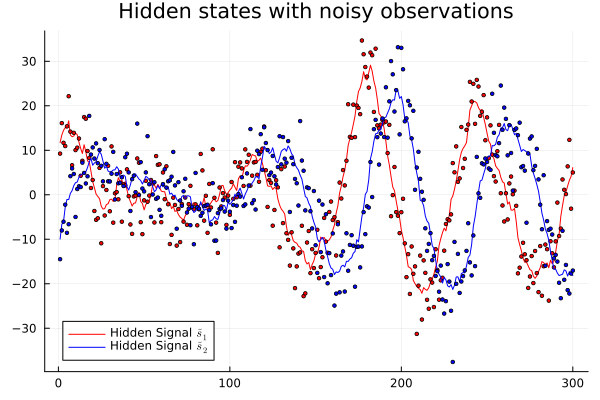

In [11]:
_p = plot(title="Hidden states with noisy observations")
_p = plot!(_p, getindex.(_s̃, 1), label="Hidden Signal " * L"\tilde{s}_1", color=:red)
_p = scatter!(_p, getindex.(_y, 1), label=false, markersize=2, color=:red)

_p = plot!(_p, getindex.(_s̃, 2), label="Hidden Signal " * L"\tilde{s}_2", color=:blue)
_p = scatter!(_p, getindex.(_y, 2), label=false, markersize=2, color=:blue)
plot(_p)

## The Generative Model

To create a model we use `GraphPPL` package and `@model` macro:

In [12]:
@model function rotate_ssm(y, s₀, B, A, Q, R)
    s_prior ~ MvNormalMeanCovariance(mean(s₀), cov(s₀))
    sₜ₋₁ = s_prior
    for t in 1:length(y)
        s[t] ~ MvNormalMeanCovariance(B*sₜ₋₁, Q) ## `s` is a sequence of hidden states
        ##- s[t] ~ MvNormalMeanCovariance(f(B= B, sₜ₋₁= sₜ₋₁), Q) ## `s` is a sequence of hidden states
        y[t] ~ MvNormalMeanCovariance(A*s[t], R) ## `y` is a sequence of "clamped" observations
        sₜ₋₁ = s[t]
    end
end

To run inference we also specify a prior for our first hidden state:

In [13]:
_s̃₀ = MvNormalMeanCovariance(zeros(2), 100.0*diageye(2));

In [14]:
## For large number of observations you need to use limit_stack_depth = 100 option during model creation, e.g. 
## infer(..., options = (limit_stack_depth = 500, ))`
## We assume the _B̃, _Ã, _Q̃, _R̃ are known, i.e. not hidden  
_result = infer(
    model=       rotate_ssm(s₀=_s̃₀, B=_B̃, A=_Ã, Q=_Q̃, R=_R̃),
    data=        (y = _y,),
    free_energy= true
);

In [15]:
_result.posteriors

Dict{Symbol, Any} with 2 entries:
  :s       => MvNormalWeightedMeanPrecision{Float64, Vector{Float64}, Matrix{Fl…
  :s_prior => MvNormalWeightedMeanPrecision(…

In [16]:
_smarginals  = _result.posteriors[:s]
_logevidence = -_result.free_energy; ## given the analytical solution, free energy will be equal to the negative log evidence

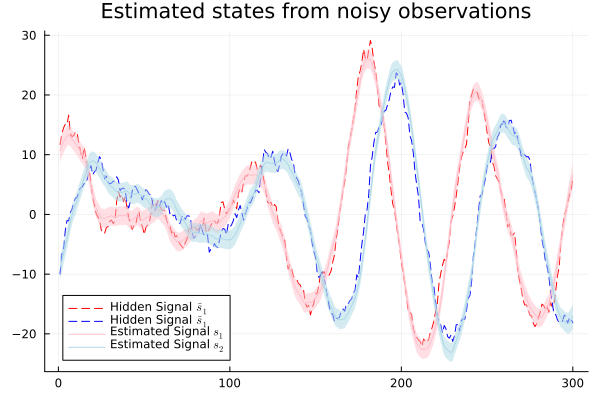

In [18]:
_p = plot(title="Estimated states from noisy observations")
_p = plot!(_p, getindex.(_s̃, 1), label="Hidden Signal " * L"\tilde{s}_1", color=:red, linestyle=:dash)
_p = plot!(_p, getindex.(_s̃, 2), label="Hidden Signal " * L"\tilde{s}_1", color=:blue, linestyle=:dash)

_p = plot!(_p, getindex.(mean.(_smarginals), 1), ribbon=getindex.(var.(_smarginals), 1) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"s_1", color=:pink)
_p = plot!(_p, getindex.(mean.(_smarginals), 2), ribbon=getindex.(var.(_smarginals), 2) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"s_2", color=:lightblue)
plot(_p)

As we can see from our plot, estimated signal resembles closely to the real hidden states with small variance. We maybe also interested in the value for minus log evidence:

In [19]:
_logevidence

1-element Vector{Float64}:
 -1882.2434870099428